# Evaluations

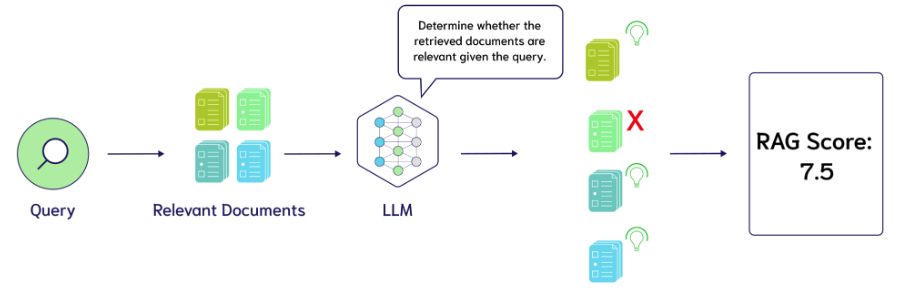

## [Evaluation Score](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/)
- `Faithfulness`: 생성된 답변의 사실적 일관성을 주어진 컨텍스트와 비교하여 측정하는 지표입니다.
- `Relevancy`: 생성된 답변이 주어진 prompt에 얼마나 적절한지를 평가하는 지표입니다.
- `Context Precision`: contexts 내의 ground-truth 관련 항목들이 상위 순위에 있는지를 평가하는 지표입니다.
- `Context recall`: 검색된 context가 LLM 이 생성한 답변과 얼마나 일치하는지를 측정합니다.

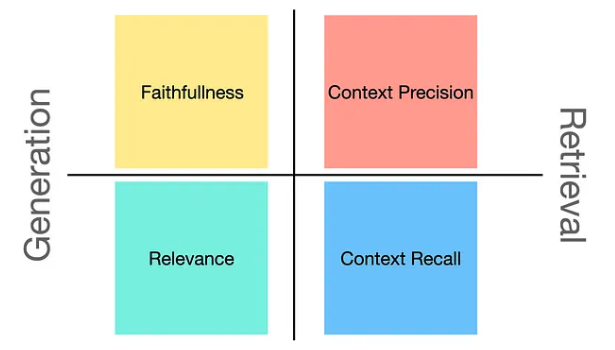

### Generation Metrics

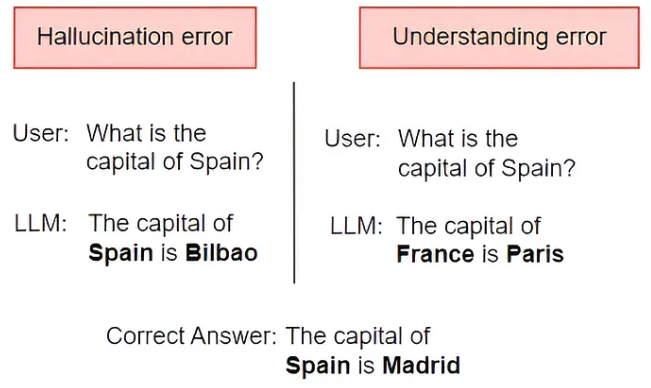

#### [Answer Relevancy](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/answer_relevance/)

- Answer Relevancy는 생성된 답변이 주어진 prompt에 얼마나 적절한지를 평가하는 지표입니다. 이 지표의 주요 특징과 계산 방법을 요약하면 다음과 같습니다:
  - `목적`: 생성된 답변의 관련성을 평가합니다.
  - `점수 해석`: 낮은 점수는 불완전하거나 중복 정보를 포함한 답변을, 높은 점수는 더 나은 관련성을 나타냅니다.
  - `계산에 사용되는 요소`: question, context, answer

#### [Faithfulness](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/faithfulness/?h=faithfulness)

- Faithfulness는 생성된 답변의 사실적 일관성을 주어진 컨텍스트와 비교하여 측정하는 지표입니다. 주요 특징은 다음과 같습니다:
  - `목적`: 답변의 사실적 일관성을 컨텍스트와 비교하여 평가합니다.
  - `계산 요소`: 답변과 검색된 컨텍스트를 사용합니다.
  - `점수 범위`: 0에서 1 사이로 조정되며, 높을수록 더 좋습니다.

- 예시
  - `질문`: "아인슈타인은 어디서, 언제 태어났나요?"
  - `컨텍스트`: "알버트 아인슈타인(1879년 3월 14일 출생)은 독일 출신의 이론 물리학자로, 역사상 가장 위대하고 영향력 있는 과학자 중 한 명으로 여겨집니다."
  - `높은 충실도 답변`: "아인슈타인은 1879년 3월 14일 독일에서 태어났습니다."
  - `낮은 충실도 답변`: "아인슈타인은 1879년 3월 20일 독일에서 태어났습니다."

### [Retrieval Metrics](https://www.pinecone.io/learn/series/vector-databases-in-production-for-busy-engineers/rag-evaluation/)

#### [Context Precision(Precision@k)](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/context_precision/)
- Context Precision은 contexts 내의 ground-truth 관련 항목들이 상위 순위에 있는지를 평가하는 지표입니다.
- 이상적으로는 모든 관련 chunks가 상위 순위에 나타나야 합니다.
- 이 지표는 question, ground_truth, 그리고 contexts를 사용하여 계산되며, 0에서 1 사이의 값을 가집니다.
- 높은 점수일수록 더 나은 정밀도를 나타냅니다.

$$
Precision@k = { true\; positives@k \over (true\; positives@k) + (false\; positives@k) }
$$

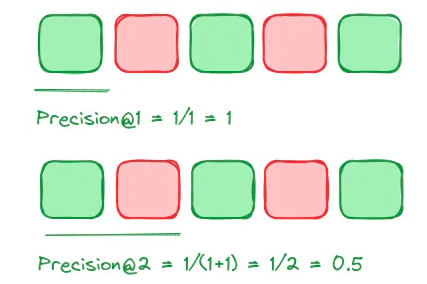

#### [Context Recall(Recall@k)](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/context_recall/)
- Context recall은 검색된 context가 LLM 이 생성한 답변과 얼마나 일치하는지를 측정합니다.
- 이는 question, ground truth 및 검색된 context를 사용하여 계산되며, 값은 0에서 1 사이로, 높을수록 더 나은 성능을 나타냅니다.
- Ground truth 답변에서 context recall을 추정하기 위해, ground truth 답변의 각 주장이 검색된 context에 귀속될 수 있는지 분석됩니다. 이상적인 시나리오에서는 ground truth 답변의 모든 주장이 검색된 context에 귀속될 수 있어야 합니다.

$$
Recall@k = { true\; positives@k \over (true\; positives@k) + (false\; negatives@k) }
$$

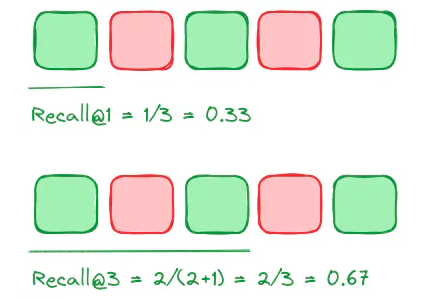

## 로드 RAG 답변 데이터셋

| Key              | 타입                   | 필수 여부        | 설명                                     |
| ---------------- | -------------------- | ------------ | -------------------------------------- |
| **question**     | `str`                | ✅ 필수         | RAGAs를 통해 생성된 테스트 질문 (prompt)                   |
| **contexts**     | `List[str]`          | ✅ 필수         | RAG 시스템이 검색(retrieve)한 문맥(Context) 리스트 |
| **answers**      | `str`                | ✅ 필수         | LLM이 생성한 답변 (RAG 응답 결과)                |
| **ground_truth** | `str` 또는 `List[str]` | ⚙️ 평가에 따라 필요 | 실제 정답 (RAGAs를 통해 생성된 테스트 질문에 대한 정답 답변)            |
| **reference_contexts** | `List[str]` | ⚙️ 평가에 따라 필요 | 실제 정답을 생성한 근거 문맥 리스트 (RAGAs를 통해 생성된 정답 답변의 근거 데이터)            |

In [1]:
import pandas as pd 

df_test = pd.read_csv("./data/evaluation_ragas_with_answer.csv")

df_test.head(2)

,question,contexts,answer,ground_truth,reference_contexts
0,"바이든 대통령이 발표한 AI 행정명령의 주요 내용은 뭐고, 그 목적은 무엇인지 설명해줘.","[""1. \uc815\ucc45/\ubc95\uc81c 2. \uae30\uc5c5...",바이든 대통령이 발표한 AI 행정명령의 주요 내용은 다음과 같습니다.\n\n* ...,바이든 대통령이 발표한 AI 행정명령은 안전하고 신뢰할 수 있는 AI 개발과 사용을...,"['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하..."
1,G7이 히로시마 AI 프로세스를 통해 AI 기업을 대상으로 마련한 국제 행동강령의 ...,"[""SPRi AI Brief |\n2023-12\uc6d4\ud638\nG7, \u...",G7이 히로시마 AI 프로세스를 통해 AI 기업 대상의 AI 국제 행동강령(Inte...,G7은 AI 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 채택을 권고하는...,"['SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스..."


In [2]:
type(df_test.loc[0,["contexts"]].values[0])

str

### contexts 문자열을 list로 형변환 

In [3]:
import json

df_test["contexts"] = df_test["contexts"].apply(json.loads)

df_test.head(2)

,question,contexts,answer,ground_truth,reference_contexts
0,"바이든 대통령이 발표한 AI 행정명령의 주요 내용은 뭐고, 그 목적은 무엇인지 설명해줘.","[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",바이든 대통령이 발표한 AI 행정명령의 주요 내용은 다음과 같습니다.\n\n* ...,바이든 대통령이 발표한 AI 행정명령은 안전하고 신뢰할 수 있는 AI 개발과 사용을...,"['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하..."
1,G7이 히로시마 AI 프로세스를 통해 AI 기업을 대상으로 마련한 국제 행동강령의 ...,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...",G7이 히로시마 AI 프로세스를 통해 AI 기업 대상의 AI 국제 행동강령(Inte...,G7은 AI 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 채택을 권고하는...,"['SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스..."


In [4]:
type(df_test.loc[0,["contexts"]].values[0])

list

### 특수 문자 등이 많이 있어서, 클린징 작업 진행 

In [5]:
df_test.loc[0,["contexts"]].values[0]

['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표\nKEY Contents\nn 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고\n광범위한 행정 조치를 명시\nn 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자\n보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\n£바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진\nn 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과\n사용을 보장하기 위한 행정명령을 발표\n∙ 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호\n△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄',
 '1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표\nKEY Contents\nn 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고\n광범위한 행정 조치를 명시\nn 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자\n보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\n£바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진\nn 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과\n사용을 보장하기 위한 행정명령을 발표\n∙ 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호\n△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄',
 '문제를 방지하는 조치를 확대\n∙ 형사사법 시스템에서 AI 사용 모범

In [6]:
import re

# 텍스트 정제 함수
def clean_text(text):
    text = text.replace("\n", " ")  # 개행 제거
    text = re.sub(r"[∙△£☞*·■◆▶◇▪•]", " ", text)  # 특정 특수문자 제거
    text = re.sub(r"[^가-힣a-zA-Z0-9.,()\s]", " ", text)  # 한글, 영문, 숫자, ., , , () 제외하고 제거
    text = re.sub(r"\s+", " ", text)  # 여러 공백 → 하나로
    return text.strip()

In [7]:
df_test["contexts"] = df_test["contexts"].map(lambda lst: [ clean_text(text) for text in lst])


In [8]:
df_test.loc[0,["contexts"]].values[0]

['1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표 KEY Contents n 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 에 서명하고 광범위한 행정 조치를 명시 n 행정명령은 AI의 안전과 보안 기준 마련 개인정보보호 형평성과 시민권 향상 소비자 보호 노동자 지원 혁신과 경쟁 촉진 국제협력을 골자로 함 바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진 n 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과 사용을 보장하기 위한 행정명령을 발표 행정명령은 AI의 안전과 보안 기준 마련 개인정보보호 형평성과 시민권 향상 소비자 보호 노동자 지원 혁신과 경쟁 촉진 국제협력에 관한 내용을 포괄',
 '1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표 KEY Contents n 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 에 서명하고 광범위한 행정 조치를 명시 n 행정명령은 AI의 안전과 보안 기준 마련 개인정보보호 형평성과 시민권 향상 소비자 보호 노동자 지원 혁신과 경쟁 촉진 국제협력을 골자로 함 바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진 n 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과 사용을 보장하기 위한 행정명령을 발표 행정명령은 AI의 안전과 보안 기준 마련 개인정보보호 형평성과 시민권 향상 소비자 보호 노동자 지원 혁신과 경쟁 촉진 국제협력에 관한 내용을 포괄',
 '문제를 방지하는 조치를 확대 형사사법 시스템에서 AI 사용 모범사례를 개발하고, 주택 임대 시 AI 알고리즘 차별을 막기 위한 명확한 지침을 제공하며, 보건복지 부문에서 책

### pandas를 dataset으로 변환 

In [9]:
from datasets import Dataset

dataset_test = Dataset.from_pandas(df_test[
    ['question', 'contexts', 'answer', 'ground_truth']])
dataset_test

Dataset({
    features: ['question', 'contexts', 'answer', 'ground_truth'],
    num_rows: 10
})

## [answer 평가 by RAGAS](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/)
- [OpenAI Key 발급](https://platform.openai.com/api-keys)

In [10]:
from dotenv import load_dotenv 

# .env 파일에 있는 데이터를 환경변수에 등록해주는 함수 
load_dotenv()

True

In [11]:
from ragas import evaluate
from ragas.metrics import (
    answer_relevancy,
    faithfulness,
    context_recall,
    context_precision,
)

### [Relevancy](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/answer_relevance/)
> 생성된 답변이 주어진 user_input에 얼마나 적절한지를 평가하는 지표입니다.

In [12]:
from langchain_openai import ChatOpenAI

result_answer_relevancy = evaluate(
    dataset=dataset_test,
    metrics=[answer_relevancy],
    llm=ChatOpenAI(model="gpt-4o-mini")
)

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

In [13]:
print(f"RAGAs의 평가결과: {result_answer_relevancy}")

RAGAs의 평가결과: {'answer_relevancy': 0.7473}


In [14]:
df_answer_relevancy = result_answer_relevancy.to_pandas()
df_answer_relevancy.head()

,user_input,retrieved_contexts,response,reference,answer_relevancy
0,"바이든 대통령이 발표한 AI 행정명령의 주요 내용은 뭐고, 그 목적은 무엇인지 설명해줘.","[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 ...",바이든 대통령이 발표한 AI 행정명령의 주요 내용은 다음과 같습니다.\n\n* ...,바이든 대통령이 발표한 AI 행정명령은 안전하고 신뢰할 수 있는 AI 개발과 사용을...,0.844830
1,G7이 히로시마 AI 프로세스를 통해 AI 기업을 대상으로 마련한 국제 행동강령의 ...,"[SPRi AI Brief 2023 12월호 G7, 히로시마 AI 프로세스를 통해 ...",G7이 히로시마 AI 프로세스를 통해 AI 기업 대상의 AI 국제 행동강령(Inte...,G7은 AI 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 채택을 권고하는...,0.878791
2,리시 수낙 총리가 AI 안전성 정상회의에서 발표한 내용은 무엇인가요?,"[중요하다고 강조했으며, 특히 최첨단 AI 시스템 개발 기업은 안전 평가를 비롯한 ...",리시 수낙 영국 총리는 AI 안전성 정상회의를 마무리하며 첨단 AI 모델에 대한 안...,리시 수낙 영국 총리는 AI 안전성 정상회의를 마무리하며 첨단 AI 모델에 대한 안...,0.824585
3,디비언트아트에 대한 저작권 소송은 어떻게 진행되었나요?,"[SPRi AI Brief 2023 12월호 미국 법원, 예술가들이 생성 AI 기업...",디비언트아트에 대한 저작권 소송은 인정되지 않았습니다. 사라 앤더슨이 저작권을 보유...,미국 캘리포니아 북부지방법원은 디비언트아트를 포함한 미드저니와 스태빌리티AI를 대상...,0.789760
4,2023년 5월 31일에 미국 연방거래위원회가 어떤 조치를 취했는지 설명해 주세요.,[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국 연방거래위원...,수제공된 컨텍스트에는 2023년 5월 31일에 미국 연방거래위원회가 어떤 조치를 ...,"2023년 5월 31일, 미국 연방거래위원회(FTC)는 동의를 받지 않고 어린이들의...",0.000000


### [Faithfulness](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/faithfulness/)
> 생성된 답변의 사실적 일관성을 주어진 컨텍스트와 비교하여 측정하는 지표입니다.

In [15]:
from langchain_openai import ChatOpenAI

result_faithfulness = evaluate(
    dataset=dataset_test,
    metrics=[faithfulness],
    llm=ChatOpenAI(model="gpt-4o-mini")
)

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

In [16]:
print(f"RAGAs의 평가결과: {result_faithfulness}")

RAGAs의 평가결과: {'faithfulness': 0.8528}


In [17]:
df_faithfulness = result_faithfulness.to_pandas()
df_faithfulness.head()

,user_input,retrieved_contexts,response,reference,faithfulness
0,"바이든 대통령이 발표한 AI 행정명령의 주요 내용은 뭐고, 그 목적은 무엇인지 설명해줘.","[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 ...",바이든 대통령이 발표한 AI 행정명령의 주요 내용은 다음과 같습니다.\n\n* ...,바이든 대통령이 발표한 AI 행정명령은 안전하고 신뢰할 수 있는 AI 개발과 사용을...,0.647059
1,G7이 히로시마 AI 프로세스를 통해 AI 기업을 대상으로 마련한 국제 행동강령의 ...,"[SPRi AI Brief 2023 12월호 G7, 히로시마 AI 프로세스를 통해 ...",G7이 히로시마 AI 프로세스를 통해 AI 기업 대상의 AI 국제 행동강령(Inte...,G7은 AI 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 채택을 권고하는...,1.000000
2,리시 수낙 총리가 AI 안전성 정상회의에서 발표한 내용은 무엇인가요?,"[중요하다고 강조했으며, 특히 최첨단 AI 시스템 개발 기업은 안전 평가를 비롯한 ...",리시 수낙 영국 총리는 AI 안전성 정상회의를 마무리하며 첨단 AI 모델에 대한 안...,리시 수낙 영국 총리는 AI 안전성 정상회의를 마무리하며 첨단 AI 모델에 대한 안...,1.000000
3,디비언트아트에 대한 저작권 소송은 어떻게 진행되었나요?,"[SPRi AI Brief 2023 12월호 미국 법원, 예술가들이 생성 AI 기업...",디비언트아트에 대한 저작권 소송은 인정되지 않았습니다. 사라 앤더슨이 저작권을 보유...,미국 캘리포니아 북부지방법원은 디비언트아트를 포함한 미드저니와 스태빌리티AI를 대상...,1.000000
4,2023년 5월 31일에 미국 연방거래위원회가 어떤 조치를 취했는지 설명해 주세요.,[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국 연방거래위원...,수제공된 컨텍스트에는 2023년 5월 31일에 미국 연방거래위원회가 어떤 조치를 ...,"2023년 5월 31일, 미국 연방거래위원회(FTC)는 동의를 받지 않고 어린이들의...",0.666667


### [Context recall](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/context_recall/)
> 검색된 context가 LLM 이 생성한 답변과 얼마나 일치하는지를 측정합니다.

In [18]:
from langchain_openai import ChatOpenAI

result_context_recall = evaluate(
    dataset=dataset_test,
    metrics=[context_recall],
    llm=ChatOpenAI(model="gpt-4o-mini")
)

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

In [19]:
print(f"RAGAs의 평가결과: {result_context_recall}")

RAGAs의 평가결과: {'context_recall': 0.8500}


In [20]:
df_context_recall = result_context_recall.to_pandas()
df_context_recall.head()

,user_input,retrieved_contexts,response,reference,context_recall
0,"바이든 대통령이 발표한 AI 행정명령의 주요 내용은 뭐고, 그 목적은 무엇인지 설명해줘.","[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 ...",바이든 대통령이 발표한 AI 행정명령의 주요 내용은 다음과 같습니다.\n\n* ...,바이든 대통령이 발표한 AI 행정명령은 안전하고 신뢰할 수 있는 AI 개발과 사용을...,1.0
1,G7이 히로시마 AI 프로세스를 통해 AI 기업을 대상으로 마련한 국제 행동강령의 ...,"[SPRi AI Brief 2023 12월호 G7, 히로시마 AI 프로세스를 통해 ...",G7이 히로시마 AI 프로세스를 통해 AI 기업 대상의 AI 국제 행동강령(Inte...,G7은 AI 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 채택을 권고하는...,1.0
2,리시 수낙 총리가 AI 안전성 정상회의에서 발표한 내용은 무엇인가요?,"[중요하다고 강조했으며, 특히 최첨단 AI 시스템 개발 기업은 안전 평가를 비롯한 ...",리시 수낙 영국 총리는 AI 안전성 정상회의를 마무리하며 첨단 AI 모델에 대한 안...,리시 수낙 영국 총리는 AI 안전성 정상회의를 마무리하며 첨단 AI 모델에 대한 안...,1.0
3,디비언트아트에 대한 저작권 소송은 어떻게 진행되었나요?,"[SPRi AI Brief 2023 12월호 미국 법원, 예술가들이 생성 AI 기업...",디비언트아트에 대한 저작권 소송은 인정되지 않았습니다. 사라 앤더슨이 저작권을 보유...,미국 캘리포니아 북부지방법원은 디비언트아트를 포함한 미드저니와 스태빌리티AI를 대상...,1.0
4,2023년 5월 31일에 미국 연방거래위원회가 어떤 조치를 취했는지 설명해 주세요.,[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국 연방거래위원...,수제공된 컨텍스트에는 2023년 5월 31일에 미국 연방거래위원회가 어떤 조치를 ...,"2023년 5월 31일, 미국 연방거래위원회(FTC)는 동의를 받지 않고 어린이들의...",0.0


### [Context Precision](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/context_precision/)
> contexts 내의 ground-truth 관련 항목들이 상위 순위에 있는지를 평가하는 지표입니다.

In [21]:
from langchain_openai import ChatOpenAI

result_context_precision = evaluate(
    dataset=dataset_test,
    metrics=[context_precision],
    llm=ChatOpenAI(model="gpt-4o-mini")
)

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

In [22]:
print(f"RAGAs의 평가결과: {result_context_precision}")

RAGAs의 평가결과: {'context_precision': 0.8917}


In [23]:
df_result_context_precision = result_context_precision.to_pandas()
df_result_context_precision.head()

,user_input,retrieved_contexts,response,reference,context_precision
0,"바이든 대통령이 발표한 AI 행정명령의 주요 내용은 뭐고, 그 목적은 무엇인지 설명해줘.","[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 ...",바이든 대통령이 발표한 AI 행정명령의 주요 내용은 다음과 같습니다.\n\n* ...,바이든 대통령이 발표한 AI 행정명령은 안전하고 신뢰할 수 있는 AI 개발과 사용을...,1.0
1,G7이 히로시마 AI 프로세스를 통해 AI 기업을 대상으로 마련한 국제 행동강령의 ...,"[SPRi AI Brief 2023 12월호 G7, 히로시마 AI 프로세스를 통해 ...",G7이 히로시마 AI 프로세스를 통해 AI 기업 대상의 AI 국제 행동강령(Inte...,G7은 AI 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 채택을 권고하는...,1.0
2,리시 수낙 총리가 AI 안전성 정상회의에서 발표한 내용은 무엇인가요?,"[중요하다고 강조했으며, 특히 최첨단 AI 시스템 개발 기업은 안전 평가를 비롯한 ...",리시 수낙 영국 총리는 AI 안전성 정상회의를 마무리하며 첨단 AI 모델에 대한 안...,리시 수낙 영국 총리는 AI 안전성 정상회의를 마무리하며 첨단 AI 모델에 대한 안...,1.0
3,디비언트아트에 대한 저작권 소송은 어떻게 진행되었나요?,"[SPRi AI Brief 2023 12월호 미국 법원, 예술가들이 생성 AI 기업...",디비언트아트에 대한 저작권 소송은 인정되지 않았습니다. 사라 앤더슨이 저작권을 보유...,미국 캘리포니아 북부지방법원은 디비언트아트를 포함한 미드저니와 스태빌리티AI를 대상...,1.0
4,2023년 5월 31일에 미국 연방거래위원회가 어떤 조치를 취했는지 설명해 주세요.,[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국 연방거래위원...,수제공된 컨텍스트에는 2023년 5월 31일에 미국 연방거래위원회가 어떤 조치를 ...,"2023년 5월 31일, 미국 연방거래위원회(FTC)는 동의를 받지 않고 어린이들의...",0.0
